In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *

In [2]:
psi = pd.read_csv(f"data/GTEx_frontal_cortex_exon_PSI.csv", index_col=0)
ctype_MEs_df = pd.read_csv("data/GTEx_frontal_cortex_TPM_OR_lmFit_residuals_Bakken_2019_meanExpr.csv", index_col=0)

## Align PSI and ME data

In [3]:
psi.columns = psi.columns.str.replace("-", ".")
psi = psi.loc[:, psi.columns.isin(ctype_MEs_df.index)]

ctype_MEs_df = ctype_MEs_df.reindex(psi.columns.values.tolist()).dropna(how="all")

In [4]:
ctype_MEs_df

,BAKKEN_2019_GABAERGIC,BAKKEN_2019_GLUTAMATERGIC,BAKKEN_2019_NON_NEURONAL,BAKKEN_2019_ASTRO,BAKKEN_2019_ENDO,BAKKEN_2019_L2_3_IT_NEURON,BAKKEN_2019_L5_ET_NEURON,BAKKEN_2019_L5_IT_NEURON,BAKKEN_2019_L5_6_NP_NEURON,BAKKEN_2019_L6_CT_NEURON,...,BAKKEN_2019_INH_L5_6_SST_PIK3CD,BAKKEN_2019_INH_L5_6_VIP_COL4A3,BAKKEN_2019_INH_L6_SST_TH,BAKKEN_2019_MICRO_L1_6_TYROBP_CD74,BAKKEN_2019_OPC_L1_6_PDGFRA_COL20A1,BAKKEN_2019_OLIGO_L2_6_OPALIN_FTH1P3,BAKKEN_2019_OLIGO_L2_6_OPALIN_MAP6D1,BAKKEN_2019_OLIGO_L3_6_OPALIN_ENPP6,BAKKEN_2019_OLIGO_L5_6_OPALIN_LDLRAP1,BAKKEN_2019_VLMC_L1_5_PDGFRA_COLEC12
GTEX.1117F.0011.R10b.SM.GI4VE,67.493872,41.644425,2.974509,NaN,65.534349,18.521744,NaN,35.399629,NaN,23.886331,...,0.486154,20.459099,0.488211,10.295311,7.278026,41.885272,403.436750,256.806923,7.346293,10.464578
GTEX.111FC.0011.R10a.SM.GIN8G,140.780697,62.414649,2.603400,NaN,61.740291,30.666094,NaN,39.060484,NaN,23.864574,...,1.255770,11.539971,0.582027,11.277235,4.904992,42.851410,221.326026,174.218989,5.026307,8.834344
GTEX.117XS.0011.R10b.SM.GIN8Z,126.499147,58.244831,2.526065,NaN,72.298255,30.296133,NaN,35.134473,NaN,23.799359,...,1.025336,11.540125,0.542033,8.527330,4.846530,37.767015,223.425873,168.226877,4.869157,9.669542
GTEX.1192X.0011.R10a.SM.DO941,84.079430,59.944469,2.408332,NaN,64.608985,39.559874,NaN,35.225570,NaN,18.212003,...,0.870703,14.984361,0.547971,10.461050,5.237089,37.218502,203.272373,221.538344,4.634435,8.208394
GTEX.11DXY.0011.R10b.SM.DO12C,133.321378,59.002442,2.696381,NaN,65.301959,30.021814,NaN,33.257807,NaN,21.566338,...,1.044647,12.010229,0.541113,9.611055,4.348200,43.614145,239.665967,184.970403,4.933836,9.024867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTEX.ZVT3.0011.R10b.SM.57WB6,88.838144,45.395480,2.528255,NaN,82.165680,32.051217,NaN,26.131168,NaN,17.669112,...,0.840223,15.147886,0.543619,10.652296,6.063805,32.817975,269.850221,230.955771,4.924386,11.765870
GTEX.ZVZQ.0011.R10b.SM.51MRT,107.414748,53.988059,4.382742,NaN,74.765316,19.785667,NaN,31.010285,NaN,34.523949,...,0.785019,15.343330,1.165646,9.476220,5.067437,69.556851,293.103355,221.526739,7.402964,12.246661
GTEX.ZXG5.0011.R10a.SM.57WDD,89.706300,41.232365,3.810002,NaN,58.480844,29.530199,NaN,29.762732,NaN,31.009826,...,0.843698,14.570612,0.304044,10.548218,7.737893,40.449960,672.454282,296.678561,5.904917,13.417038
GTEX.ZYFD.0011.R10a.SM.GPI91,121.855642,54.383562,2.337464,NaN,68.642056,31.991981,NaN,30.552197,NaN,26.378614,...,1.289640,10.753088,0.593755,6.424912,5.074734,34.529274,311.995703,217.008792,4.547570,8.436360


## Annotate exons

In [5]:
# Parse GTF attribute column
gtf_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/gencode.v46.annotation.gtf"
gtf = gtf_parse(gtf_file)
gtf_subset = gtf.loc[gtf['feature'].isin(["gene"])]
attrs = gtf_subset["attribute"].apply(extract_attributes)
attrs_df = attrs.apply(pd.Series)
gtf_parsed = pd.concat([gtf_subset.drop(columns=["attribute"]), attrs_df], axis=1)

In [6]:
# Get PSI and GTF data ready to merge on gene IDs
gtf_parsed['gene_id'] = gtf_parsed['gene_id'].str.split(".").str[0]
psi['gene_id'] = psi.index.str.split("_").str[0]
psi['exon_id'] = psi.index.values

In [7]:
psi_anno = pd.merge(gtf_parsed[['gene_id', 'gene_name']], psi, on="gene_id", how="right")
psi_anno = psi_anno.set_index("exon_id").rename_axis(None)
psi_anno = psi_anno.drop(columns=["gene_id"])

In [8]:
psi_anno.shape

(44607, 187)

## Calc corrs

In [10]:
corr_df = pd.DataFrame(
    columns=["Gene"] + ctype_MEs_df.columns.values.tolist(), 
    index=psi_anno.index
)
corr_df['Gene'] = psi_anno['gene_name'] 

In [ ]:
for i, mod_eig in ctype_MEs_df.transpose().iterrows():
    corr_df[i] = psi_anno.iloc[:, 1:].corrwith(mod_eig, axis=1)

/mnt/lareaulab/reliscu/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/lareaulab/reliscu/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [97]:
corr_df.head()

,Gene,BAKKEN_2019_PVALB_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_VIP_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_SST_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_LAMP5_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_SNCG_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_SST_CHODL_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_L5_6_NP_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6_CT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L5_IT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6_IT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L5_ET_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L2_3_IT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6B_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6_IT_CAR3_GLUTAMATERGIC_DE_GLUT_CLUSTERS
ENSG00000292994_other_1,ENSG00000292994,0.141118,0.127471,0.134692,0.134472,0.134912,0.135257,0.143524,0.140480,0.134994,0.132933,0.140806,0.122411,0.136461,0.138460
ENSG00000290385_other_1,ENSG00000290385,-0.086316,-0.070943,-0.091489,-0.083704,-0.088645,-0.090403,-0.085447,-0.091948,-0.076953,-0.091870,-0.088005,-0.068386,-0.103358,-0.095890
ENSG00000290385_other_2,ENSG00000290385,-0.172647,-0.159265,-0.175561,-0.167475,-0.170914,-0.170423,-0.170529,-0.174216,-0.159685,-0.164089,-0.175750,-0.152015,-0.176944,-0.167227
ENSG00000290385_other_3,ENSG00000290385,0.301897,0.293941,0.301705,0.301841,0.309594,0.305618,0.301650,0.304085,0.297368,0.316773,0.300576,0.306833,0.312540,0.318067
ENSG00000290385_other_4,ENSG00000290385,0.386332,0.378851,0.385245,0.387004,0.393948,0.388258,0.372073,0.374151,0.384456,0.399098,0.380113,0.384845,0.381981,0.396826


GTEX.1117F.0011.R10b.SM.GI4VE   -0.084877
GTEX.111FC.0011.R10a.SM.GIN8G    0.112666
GTEX.117XS.0011.R10b.SM.GIN8Z    0.088122
GTEX.1192X.0011.R10a.SM.DO941    0.040883
GTEX.11DXY.0011.R10b.SM.DO12C    0.092753
                                   ...   
GTEX.ZVT3.0011.R10b.SM.57WB6    -0.028309
GTEX.ZVZQ.0011.R10b.SM.51MRT     0.016920
GTEX.ZXG5.0011.R10a.SM.57WDD    -0.044743
GTEX.ZYFD.0011.R10a.SM.GPI91     0.041521
GTEX.ZZPT.0011.R10b.SM.GPI8B    -0.056143
Name: BAKKEN_2019_PVALB_GABAERGIC_DE_GABA_CLUSTERS, Length: 186, dtype: float64

In [113]:
temp = psi_anno.loc['ENSG00000141503_ProteinCoding_3'].iloc[1:]

In [114]:
temp

GTEX.1117F.0011.R10b.SM.GI4VE    0.378723
GTEX.111FC.0011.R10a.SM.GIN8G    0.807927
GTEX.117XS.0011.R10b.SM.GIN8Z    0.788584
GTEX.1192X.0011.R10a.SM.DO941    0.620155
GTEX.11DXY.0011.R10b.SM.DO12C    0.797153
                                   ...   
GTEX.ZVT3.0011.R10b.SM.57WB6     0.454545
GTEX.ZVZQ.0011.R10b.SM.51MRT     0.575179
GTEX.ZXG5.0011.R10a.SM.57WDD     0.408333
GTEX.ZYFD.0011.R10a.SM.GPI91      0.62807
GTEX.ZZPT.0011.R10b.SM.GPI8B     0.413978
Name: ENSG00000141503_ProteinCoding_3, Length: 186, dtype: object

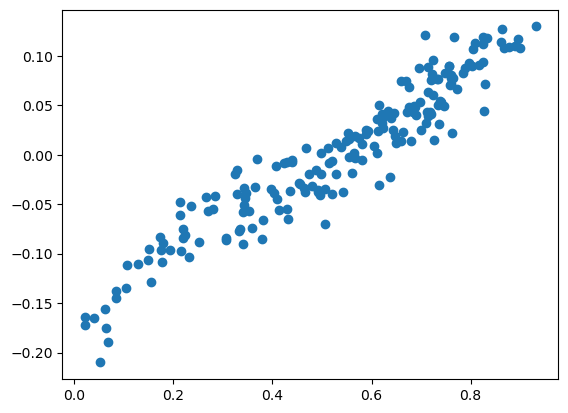

In [115]:
plt.scatter(psi_anno.loc['ENSG00000141503_ProteinCoding_3'].iloc[1:], ctype_MEs_df['BAKKEN_2019_PVALB_GABAERGIC_DE_GABA_CLUSTERS'])

In [103]:
import matplotlib.pyplot as plt

In [101]:
corr_df.sort_values("BAKKEN_2019_PVALB_GABAERGIC_DE_GABA_CLUSTERS", ascending=False).head(n=20)

,Gene,BAKKEN_2019_PVALB_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_VIP_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_SST_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_LAMP5_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_SNCG_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_SST_CHODL_GABAERGIC_DE_GABA_CLUSTERS,BAKKEN_2019_L5_6_NP_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6_CT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L5_IT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6_IT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L5_ET_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L2_3_IT_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6B_GLUTAMATERGIC_DE_GLUT_CLUSTERS,BAKKEN_2019_L6_IT_CAR3_GLUTAMATERGIC_DE_GLUT_CLUSTERS
ENSG00000141503_ProteinCoding_3,MINK1,0.951347,0.948625,0.951865,0.948182,0.956937,0.954678,0.945226,0.944811,0.947107,0.956978,0.957141,0.933509,0.951559,0.959523
ENSG00000084234_ProteinCoding_4,APLP2,0.944161,0.921955,0.943498,0.934386,0.943726,0.952434,0.950079,0.949607,0.925520,0.940432,0.948503,0.891710,0.954195,0.951011
ENSG00000138279_ProteinCoding_1,ANXA7,0.942039,0.926117,0.945608,0.935300,0.944035,0.952781,0.952353,0.948452,0.934765,0.939528,0.948230,0.901491,0.953543,0.951085
ENSG00000198792_ProteinCoding_1,TMEM184B,0.938950,0.915690,0.932819,0.926897,0.937262,0.940038,0.936201,0.930617,0.923415,0.922794,0.942578,0.890645,0.935254,0.938397
ENSG00000125991_ProteinCoding_2,ERGIC3,0.936493,0.916110,0.936076,0.919794,0.933750,0.947433,0.933835,0.926159,0.923798,0.930779,0.945931,0.897690,0.940217,0.944505
ENSG00000196776_ProteinCoding_2,CD47,0.935438,0.919290,0.922086,0.921825,0.927786,0.927798,0.928542,0.924384,0.931376,0.917988,0.935694,0.900751,0.921163,0.929242
ENSG00000110075_ProteinCoding_13,PPP6R3,0.934714,0.915937,0.929079,0.926954,0.928897,0.931554,0.928004,0.920732,0.925761,0.915926,0.936515,0.898930,0.925010,0.927967
ENSG00000106554_ProteinCoding_1,CHCHD3,0.933532,0.912451,0.931207,0.919814,0.931015,0.937772,0.930104,0.926665,0.921527,0.924823,0.939183,0.900383,0.932466,0.936883
ENSG00000077380_ProteinCoding_5,DYNC1I2,0.932648,0.913321,0.921572,0.913271,0.922328,0.928099,0.919744,0.906382,0.918634,0.912108,0.934621,0.903291,0.915445,0.925959
ENSG00000073921_ProteinCoding_6,PICALM,0.931508,0.908497,0.921345,0.915535,0.921831,0.924533,0.915207,0.902823,0.922533,0.908653,0.929053,0.905347,0.911042,0.922495
